# Test du modèle poumons 

In [2]:
import os
import numpy as np
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

CHEMIN_MODELE = r"C:\Users\gatta\OneDrive\Documents\py\detection-anomalie\detection-maladies-multi-organes\models\cerveau_classification_model.keras"
DOSSIER_TEST = r"C:\Users\gatta\OneDrive\Documents\py\detection-anomalie\detection-maladies-multi-organes\data\dataset_subsets_cerveau\test"
IMG_DIMS = 224
model = load_model(CHEMIN_MODELE)
print("Modèle chargé :", CHEMIN_MODELE)
model.summary()


Modèle chargé : C:\Users\gatta\OneDrive\Documents\py\detection-anomalie\detection-maladies-multi-organes\models\cerveau_classification_model.keras


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50176)          │       200,704 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    51,381,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,566,414 (623.96 MB)

 Trainable params: 52,141,828 (198.91 MB)

 Non-trainable params: 7,140,928 (27.24 MB)

 Optimizer params: 104,283,658 (397.81 MB)

## 1. Recharger les images de test

In [3]:
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = test_datagen.flow_from_directory(
    DOSSIER_TEST,
    target_size=(IMG_DIMS, IMG_DIMS),
    color_mode="rgb",
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)

noms_classes = list(test_gen.class_indices.keys())
print("Classes (dans cet ordre) :", noms_classes)


Found 1440 images belonging to 4 classes.
Classes (dans cet ordre) : ['glioma', 'meningioma', 'notumor', 'pituitary']


## 2. Évaluation chiffrée sur le jeu de test


In [4]:
resultat = model.evaluate(test_gen)
print(dict(zip(model.metrics_names, resultat)))

predictions = model.predict(test_gen)
y_true = test_gen.labels
y_pred = np.argmax(predictions, axis=1)

print(classification_report(y_true, y_pred, target_names=noms_classes))


45/45 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - categorical_accuracy: 0.9799 - loss: 0.0702 - precision: 0.9826 - recall: 0.9792
{'loss': 0.07017462700605392, 'compile_metrics': 0.9798611402511597}
45/45 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step
              precision    recall  f1-score   support

      glioma       0.99      0.96      0.98       360
  meningioma       0.96      0.97      0.97       360
     notumor       0.99      1.00      0.99       360
   pituitary       0.97      0.99      0.98       360

    accuracy                           0.98      1440
   macro avg       0.98      0.98      0.98      1440
weighted avg       0.98      0.98      0.98      1440



## 3. Matrice de confusion


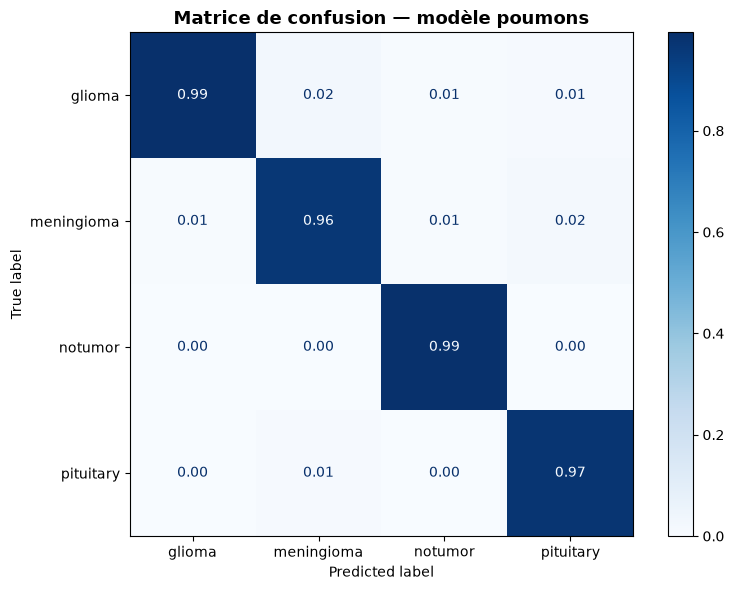

In [5]:
fig, ax = plt.subplots(facecolor="white", figsize=(8, 6), dpi=100)
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, display_labels=noms_classes,
    include_values=True, normalize="pred", values_format=".2f",
    cmap="Blues", ax=ax
)
plt.title("Matrice de confusion — modèle poumons", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("matrice_confusion_test.png", dpi=150)
plt.show()


## 4. Grad-CAM


In [6]:
def generer_gradcam(model, img_array, nom_derniere_couche_conv="relu"):
    base_model = model.layers[0]
    derniere_couche_conv = base_model.get_layer(nom_derniere_couche_conv)
    modele_conv = tf.keras.models.Model(base_model.input, derniere_couche_conv.output)

    with tf.GradientTape() as tape:
        sortie_conv = modele_conv(img_array, training=False)
        tape.watch(sortie_conv)
        x = sortie_conv
        for couche in model.layers[1:]:
            x = couche(x, training=False)
        predictions = x
        indice_classe = tf.argmax(predictions[0])
        score_classe = predictions[:, indice_classe]

    gradients = tape.gradient(score_classe, sortie_conv)
    gradients_moyennes = tf.reduce_mean(gradients, axis=(0, 1, 2))
    sortie_conv = sortie_conv[0]
    carte_chaleur = sortie_conv @ gradients_moyennes[..., tf.newaxis]
    carte_chaleur = tf.squeeze(carte_chaleur)
    carte_chaleur = tf.maximum(carte_chaleur, 0) / (tf.math.reduce_max(carte_chaleur) + 1e-8)
    return carte_chaleur.numpy(), int(indice_classe.numpy())


def preparer_image(chemin_image, taille=IMG_DIMS):
    image_pil = Image.open(chemin_image).convert("RGB").resize((taille, taille))
    tableau = np.array(image_pil).astype("float32")
    tableau_pretraite = preprocess_input(tableau.copy())
    return image_pil, tableau_pretraite.reshape(1, taille, taille, 3)


def superposer_chaleur(image_pil, carte_chaleur, taille=IMG_DIMS):
    carte_redim = np.array(Image.fromarray(carte_chaleur).resize((taille, taille)))
    colormap = matplotlib.colormaps["jet"]
    carte_couleur = (colormap(carte_redim)[:, :, :3] * 255).astype("uint8")
    return (0.6 * np.array(image_pil) + 0.4 * carte_couleur).astype("uint8")


29 erreurs sur 1440 images de test (2.0%)


c:\Users\gatta\OneDrive\Documents\py\detection-anomalie\detection-maladies-multi-organes\venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


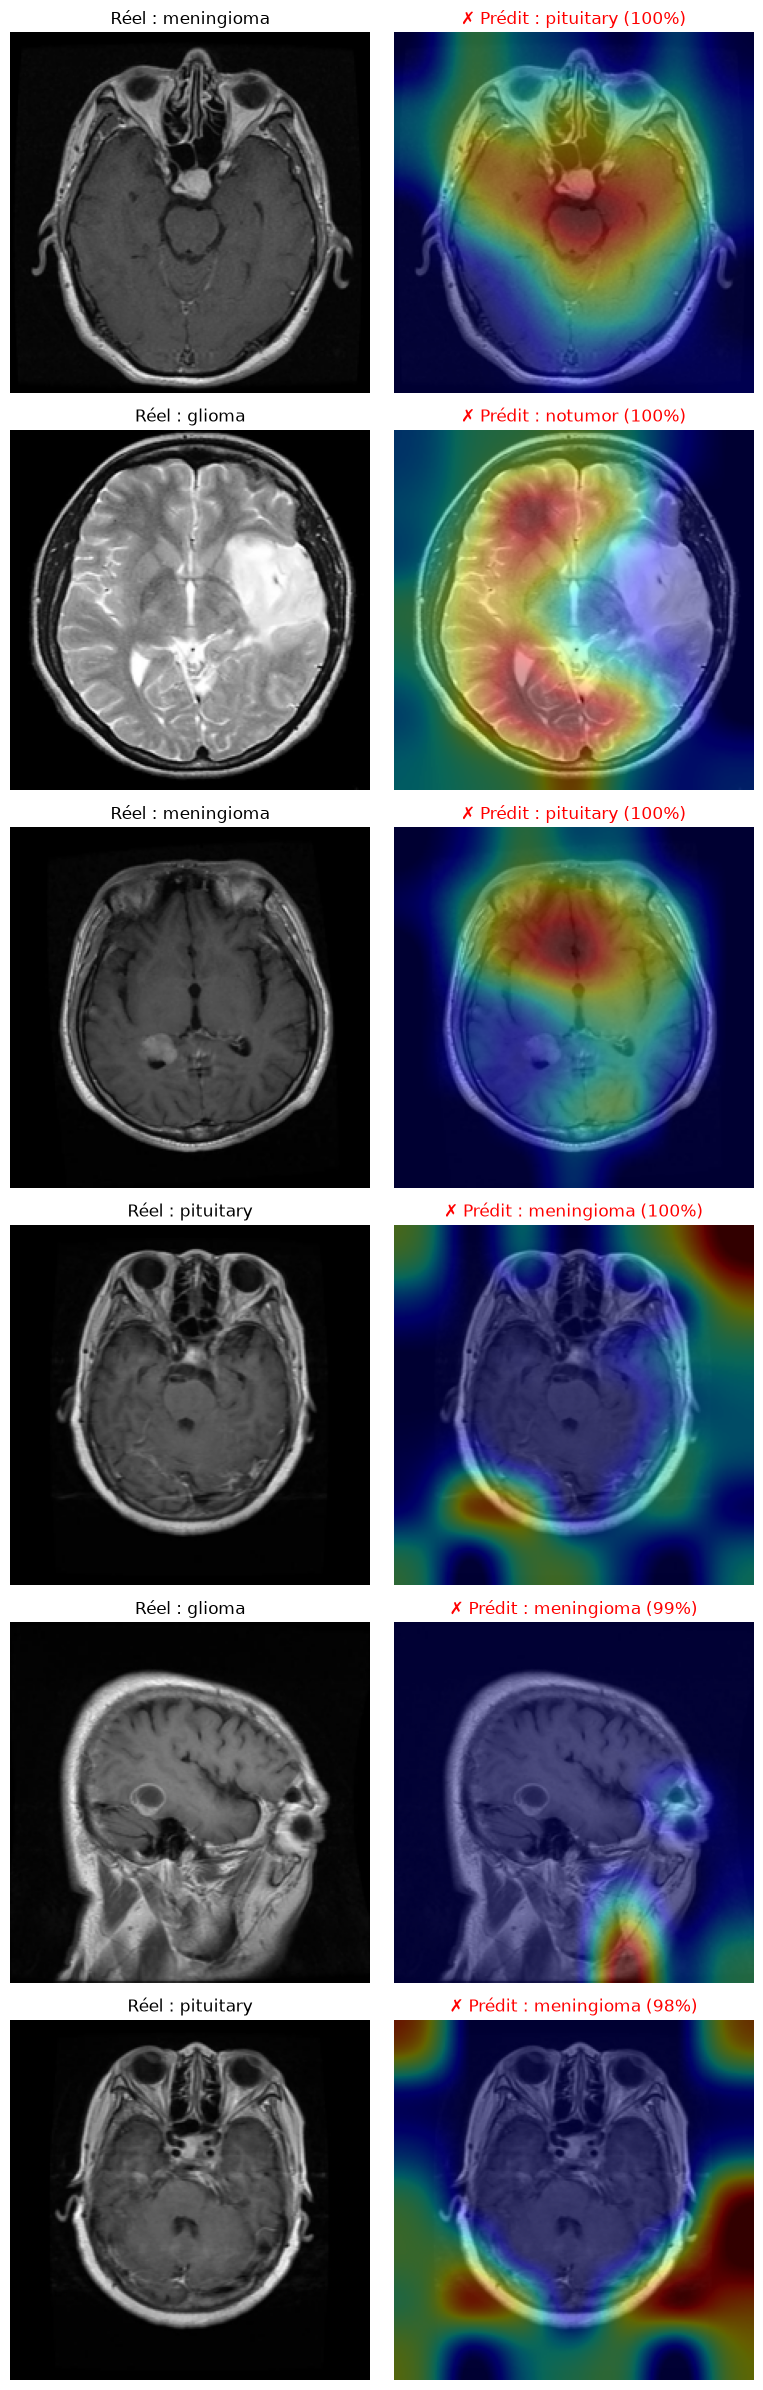

In [7]:
y_pred_classe = np.argmax(predictions, axis=1)
confiances = np.max(predictions, axis=1)

chemins_fichiers = test_gen.filepaths
erreurs = [
    (chemins_fichiers[i], noms_classes[y_true[i]], noms_classes[y_pred_classe[i]], confiances[i])
    for i in range(len(y_true)) if y_true[i] != y_pred_classe[i]
]
erreurs_triees = sorted(erreurs, key=lambda x: x[3], reverse=True)  

print(f"{len(erreurs)} erreurs sur {len(y_true)} images de test ({len(erreurs)/len(y_true):.1%})")

N_A_MONTRER = 6
fig, axes = plt.subplots(N_A_MONTRER, 2, figsize=(8, 4 * N_A_MONTRER))

for i, (chemin, vraie_classe, classe_predite, conf) in enumerate(erreurs_triees[:N_A_MONTRER]):
    image_pil, tableau = preparer_image(chemin)
    carte_chaleur, _ = generer_gradcam(model, tableau)
    superposition = superposer_chaleur(image_pil, carte_chaleur)

    axes[i, 0].imshow(image_pil)
    axes[i, 0].set_title(f"Réel : {vraie_classe}")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(superposition)
    axes[i, 1].set_title(f"✗ Prédit : {classe_predite} ({conf:.0%})", color="red")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig("erreurs_confiantes.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. un exemple détaillé


Image réelle       : glioma
Prédiction modèle  : glioma (89% de confiance)


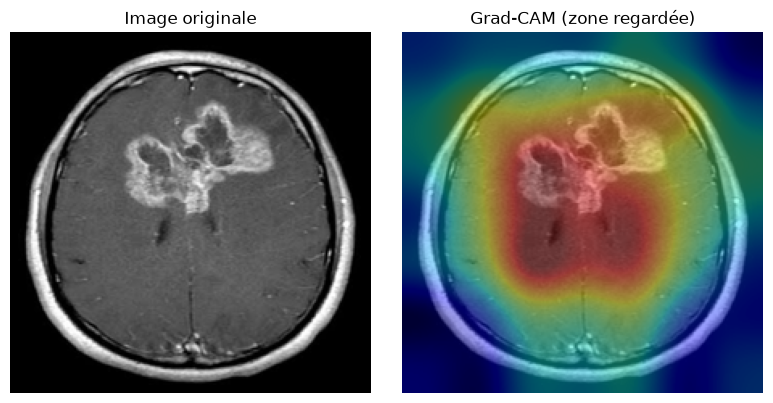

In [8]:
classe_a_tester = noms_classes[0]
dossier_classe = os.path.join(DOSSIER_TEST, classe_a_tester)
nom_image = os.listdir(dossier_classe)[0]
chemin_image = os.path.join(dossier_classe, nom_image)

image_pil, tableau = preparer_image(chemin_image)
proba = model.predict(tableau, verbose=0)[0]
indice_predit = np.argmax(proba)

print(f"Image réelle       : {classe_a_tester}")
print(f"Prédiction modèle  : {noms_classes[indice_predit]} ({proba[indice_predit]:.0%} de confiance)")

carte_chaleur, _ = generer_gradcam(model, tableau)
superposition = superposer_chaleur(image_pil, carte_chaleur)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(image_pil)
plt.title("Image originale")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(superposition)
plt.title("Grad-CAM (zone regardée)")
plt.axis("off")
plt.tight_layout()
plt.show()


## 6. Grille de plusieurs exemples

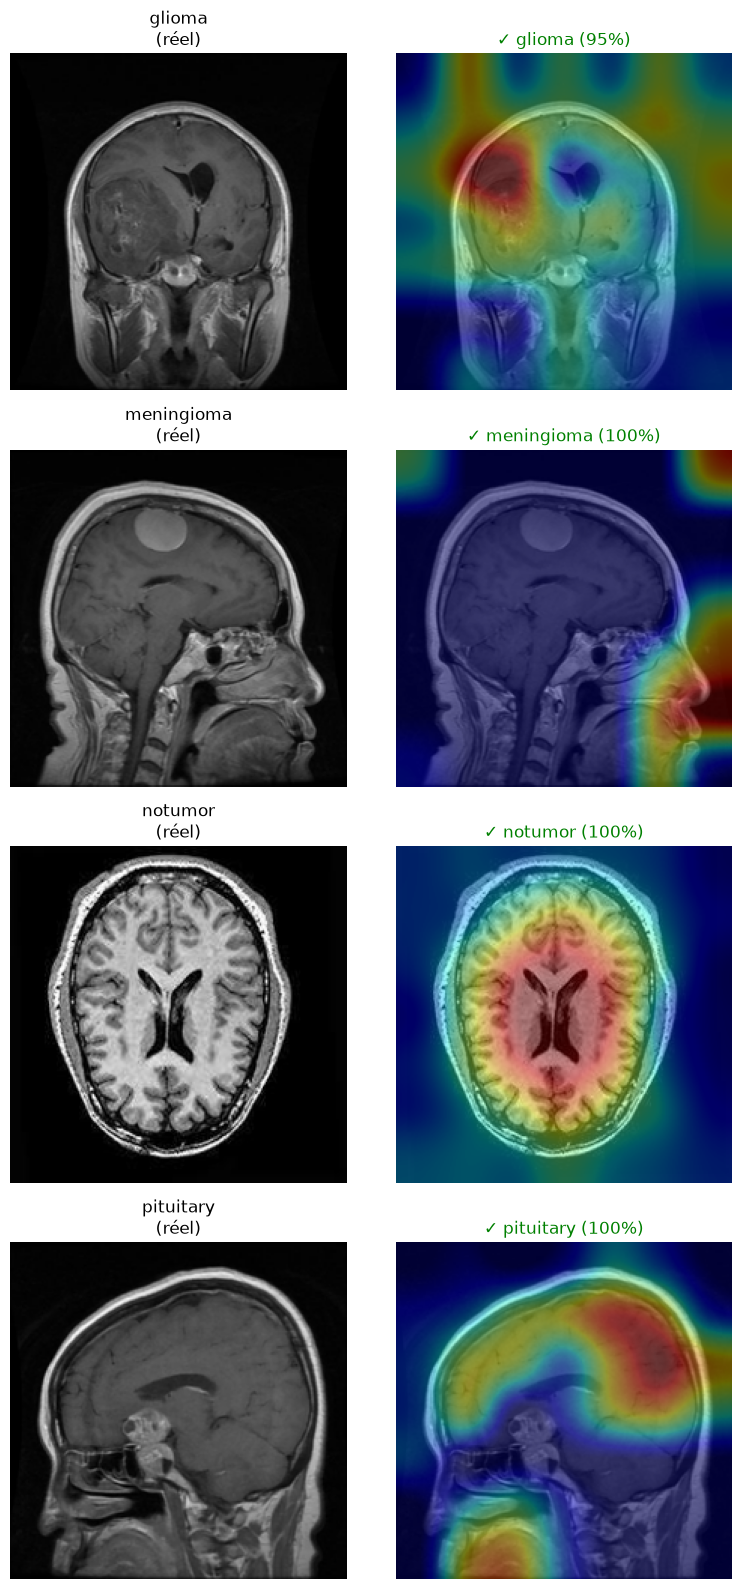

In [9]:
import random
random.seed(42)

fig, axes = plt.subplots(len(noms_classes), 2, figsize=(8, 4 * len(noms_classes)))

for i, classe in enumerate(noms_classes):
    dossier_classe = os.path.join(DOSSIER_TEST, classe)
    nom_image = random.choice(os.listdir(dossier_classe))
    chemin_image = os.path.join(dossier_classe, nom_image)

    image_pil, tableau = preparer_image(chemin_image)
    proba = model.predict(tableau, verbose=0)[0]
    indice_predit = np.argmax(proba)
    prediction = noms_classes[indice_predit]
    confiance = proba[indice_predit]
    correct = (prediction == classe)

    carte_chaleur, _ = generer_gradcam(model, tableau)
    superposition = superposer_chaleur(image_pil, carte_chaleur)

    axes[i, 0].imshow(image_pil)
    axes[i, 0].set_title(f"{classe}\n(réel)")
    axes[i, 0].axis("off")

    couleur = "green" if correct else "red"
    symbole = "✓" if correct else "✗"
    axes[i, 1].imshow(superposition)
    axes[i, 1].set_title(f"{symbole} {prediction} ({confiance:.0%})", color=couleur)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig("grille_gradcam_test.png", dpi=150, bbox_inches="tight")
plt.show()
